<a href="https://colab.research.google.com/github/dalmasm/Data_Engineer/blob/Data-Science/Linear_regression_house_prices_using_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset de entrenamiento (sin normalizar):
[[ 7.49080238e+01  1.00000000e+00  1.00000000e+00  1.11360252e+01
   1.00000000e+00  1.43357201e+05]
 [ 1.90142861e+02  4.00000000e+00  1.00000000e+00  1.87230955e+01
   4.80000000e+01  3.52349831e+05]
 [ 1.46398788e+02  5.00000000e+00  2.00000000e+00  1.39205959e+01
   2.70000000e+01  3.16042572e+05]
 [ 1.19731697e+02  4.00000000e+00  3.00000000e+00  1.14012234e+01
   3.10000000e+01  2.63830285e+05]
 [ 3.12037281e+01  5.00000000e+00  3.00000000e+00  1.94352988e+00
   2.60000000e+01  1.11985401e+05]
 [ 3.11989041e+01  5.00000000e+00  2.00000000e+00  1.23001445e+01
   1.90000000e+01  8.35092041e+04]
 [ 1.16167224e+01  3.00000000e+00  2.00000000e+00  1.98010770e+01
   2.30000000e+01 -1.93699636e+04]
 [ 1.73235229e+02  5.00000000e+00  3.00000000e+00  2.80168030e+00
   1.10000000e+01  4.19669733e+05]
 [ 1.20223002e+02  4.00000000e+00  3.00000000e+00  1.03665930e+01
   4.90000000e+01  2.56355300e+05]
 [ 1.41614516e+02  5.00000000e+00  2.00000000e+0

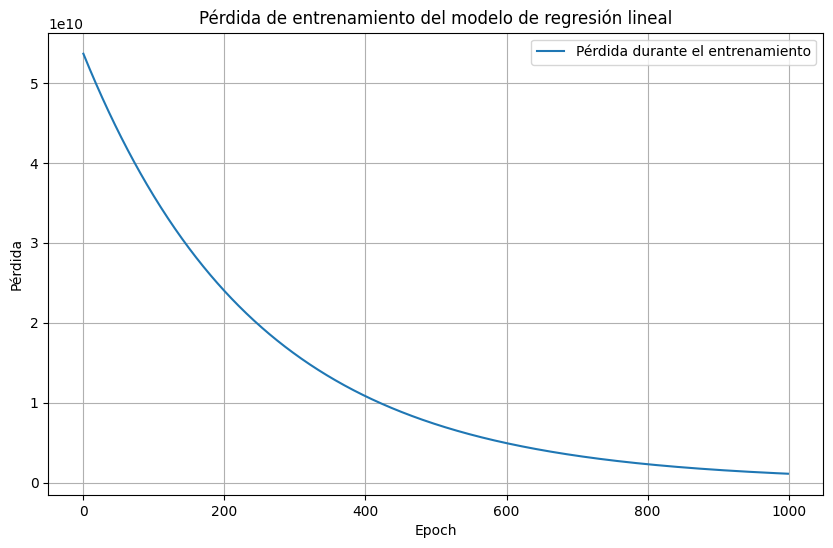

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


# Generar algunos datos de ejemplo
# A esto le llamamos "dataset sintetico", dado que los
# datos son generados artificialmente, y no vienen de captura previa
np.random.seed(42)
sizes = np.random.rand(100, 1) * 200  # Tamaños entre 0 y 200 metros cuadrados
bedrooms = np.random.randint(1, 6, (100, 1))  # Número de dormitorios entre 1 y 5
bathrooms = np.random.randint(1, 4, (100, 1))  # Número de baños entre 1 y 3
distances = np.random.rand(100, 1) * 20  # Distancia entre 0 y 20 km
ages = np.random.randint(0, 50, (100, 1))  # Edad entre 0 y 50 años
# Generar precios
prices = (2000 * sizes) + (10000 * bedrooms) + (5000 * bathrooms) - (3000 * distances) - (100 * ages) + np.random.randn(100, 1) * 10000

# Crear el dataset de entrenamiento
training_data = np.hstack((sizes, bedrooms, bathrooms, distances, ages, prices))
print("Dataset de entrenamiento (sin normalizar):")
print(training_data)

# Normalizar los datos
scaler = StandardScaler()
X = training_data[:, :-1]  # Todas las columnas excepto la última son características
y = training_data[:, -1:]  # La última columna es la etiqueta (precio)
X = scaler.fit_transform(X)
y = prices

# Convertir los datos a tensores de PyTorch
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# Definir el modelo de regresión lineal
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        out = self.linear(x)
        return out

input_dim = X.shape[1]
output_dim = 1
model = LinearRegressionModel(input_dim, output_dim)

# Definir la función de pérdida y el optimizador
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)  # Tasa de aprendizaje reducida

# Entrenar el modelo
num_epochs = 1000
losses = []
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')



# Graficar la pérdida durante el entrenamiento
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), losses, label='Pérdida durante el entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Pérdida')
plt.title('Pérdida de entrenamiento del modelo de regresión lineal')
plt.legend()
plt.grid(True)
plt.show()

In [6]:

# Normalizar la entrada del usuario usando misma escala
def normalize_input(data):
    return scaler.transform(np.array(data).reshape(1, -1))

# Hacer una predicción basada en la entrada del usuario
def predict_price(size, bedrooms, bathrooms, distance, age):
    user_input = normalize_input([size, bedrooms, bathrooms, distance, age])
    user_input_tensor = torch.tensor(user_input, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        predicted_price = model(user_input_tensor).item()
    return predicted_price

In [7]:

# Obtener entrada del usuario
size_input = float(input("Introduce el tamaño de la casa (en metros cuadrados): "))
bedrooms_input = int(input("Introduce el número de dormitorios: "))
bathrooms_input = int(input("Introduce el número de baños: "))
distance_input = float(input("Introduce la distancia al centro de la ciudad (en km): "))
age_input = int(input("Introduce la edad de la casa (en años): "))


Introduce el tamaño de la casa (en metros cuadrados): 150
Introduce el número de dormitorios: 3
Introduce el número de baños: 2
Introduce la distancia al centro de la ciudad (en km): 6
Introduce la edad de la casa (en años): 7


In [8]:

# Predecir y mostrar el precio
predicted_price = predict_price(size_input, bedrooms_input, bathrooms_input, distance_input, age_input)
print(f"El precio predicho de la casa es: ${predicted_price:.2f}")

El precio predicho de la casa es: $280405.97
